# Compare all confidence experiments

This notebook only reads already-generated output CSV files. It does not import the training/evaluation common module, reload models, or recompute metrics.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path(r"C:\\Users\\solok\\Desktop\\Dcase baseline")
OUTPUT_BASE = ROOT / "baseline_confidnce_train" / "outputs"
COMPARISON_OUT = OUTPUT_BASE / "all_experiment_comparison"
COMPARISON_OUT.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = [
    {"notebook": "01", "experiment": "01_v2_5class", "name": "01 v2 5-class", "output_dir": OUTPUT_BASE / "v2_5class"},
    {"notebook": "02", "experiment": "02_v3_binary", "name": "02 v3 binary", "output_dir": OUTPUT_BASE / "v3_binary"},
    {"notebook": "03", "experiment": "03_v4_rank_average", "name": "03 v4 rank-average", "output_dir": OUTPUT_BASE / "v4_rank_average"},
    {"notebook": "04", "experiment": "04_517_mlp_classification", "name": "04 5-17 MLP classification", "output_dir": OUTPUT_BASE / "517_mlp_classification"},
    {"notebook": "05", "experiment": "05_517_regression", "name": "05 5-17 regression", "output_dir": OUTPUT_BASE / "517_regression"},
]

METRICS = [
    "accuracy",
    "hierarchical_accuracy",
    "hierarchical_f1",
    "hierarchical_precision",
    "hierarchical_recall",
    "macro_accuracy",
    "macro_top_accuracy",
    "top_accuracy",
]

PRIMARY_METRICS = ["hierarchical_accuracy", "hierarchical_f1", "accuracy", "top_accuracy"]
EXPERIMENT_ORDER = [exp["name"] for exp in EXPERIMENTS]

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)


## Load final CSV outputs

The loader prefers likely final result files by filename, then falls back to the newest CSV in each experiment output directory.

In [ ]:
PREFERRED_FILE_KEYWORDS = [
    "summary",
    "comparison",
    "evaluation",
    "metrics",
    "result",
    "score",
]

COUNT_COLUMNS = [
    "dataset_size",
    "n_samples",
    "num_samples",
    "sample_count",
    "count",
    "n",
]


def list_csv_files(output_dir):
    if not output_dir.exists():
        return []
    return sorted(output_dir.glob("*.csv"), key=lambda path: path.stat().st_mtime, reverse=True)


def choose_result_csv(output_dir):
    csv_files = list_csv_files(output_dir)
    if not csv_files:
        return None

    lower_names = [(path, path.name.lower()) for path in csv_files]
    for keyword in PREFERRED_FILE_KEYWORDS:
        matches = [path for path, name in lower_names if keyword in name]
        if matches:
            return matches[0]
    return csv_files[0]


def numeric_last_value(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        return np.nan
    return values.iloc[-1]


def extract_dataset_count(df):
    for column in COUNT_COLUMNS:
        if column in df.columns:
            value = numeric_last_value(df[column])
            if pd.notna(value):
                return int(value)
    return len(df)


def extract_metrics_from_csv(csv_path, exp):
    df = pd.read_csv(csv_path)
    row = {
        "notebook": exp["notebook"],
        "experiment": exp["experiment"],
        "name": exp["name"],
        "csv_file": csv_path.name,
        "rows_in_csv": len(df),
        "dataset_count": extract_dataset_count(df),
    }

    for metric in METRICS:
        row[metric] = numeric_last_value(df[metric]) if metric in df.columns else np.nan

    return row


In [3]:
rows = []
missing = []

for exp in EXPERIMENTS:
    csv_path = choose_result_csv(exp["output_dir"])
    if csv_path is None:
        missing.append({"name": exp["name"], "output_dir": str(exp["output_dir"])})
        continue
    rows.append(extract_metrics_from_csv(csv_path, exp))

comparison_df = pd.DataFrame(rows)
if not comparison_df.empty:
    comparison_df["name"] = pd.Categorical(comparison_df["name"], categories=EXPERIMENT_ORDER, ordered=True)
    comparison_df = comparison_df.sort_values("name").reset_index(drop=True)

display(Markdown(f"Loaded **{len(comparison_df)}** experiment CSV files."))
if missing:
    display(Markdown("Missing output CSV files:"))
    display(pd.DataFrame(missing))

display(comparison_df)


Loaded **5** experiment CSV files.

,notebook,experiment,name,csv_file,rows_in_csv,dataset_count,accuracy,hierarchical_accuracy,hierarchical_f1,hierarchical_precision,hierarchical_recall,macro_accuracy,macro_top_accuracy,top_accuracy
0,01,01_v2_5class,01 v2 5-class,summary_results.csv,15,15,34.625912,41.937782,53.476493,45.976742,68.525189,29.728765,54.146799,60.127737
1,02,02_v3_binary,02 v3 binary,fold_metric_summary_by_confidence.csv,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03,03_v4_rank_average,03 v4 rank-average,fold_metric_summary_by_confidence.csv,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,04,04_517_mlp_classification,04 5-17 MLP classification,fold_metric_summary_by_confidence.csv,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05,05_517_regression,05 5-17 regression,fold_metric_summary_by_confidence.csv,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Save comparison tables

In [4]:
comparison_csv = COMPARISON_OUT / "experiment_comparison.csv"
primary_csv = COMPARISON_OUT / "experiment_primary_metrics.csv"

comparison_df.to_csv(comparison_csv, index=False, encoding="utf-8-sig")

primary_columns = ["notebook", "experiment", "name", "csv_file", "dataset_count", *PRIMARY_METRICS]
available_primary_columns = [column for column in primary_columns if column in comparison_df.columns]
primary_df = comparison_df[available_primary_columns].copy()
primary_df.to_csv(primary_csv, index=False, encoding="utf-8-sig")

display(Markdown(f"Saved: `{comparison_csv}`"))
display(Markdown(f"Saved: `{primary_csv}`"))
display(primary_df)


Saved: `C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\all_experiment_comparison\experiment_comparison.csv`

Saved: `C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\all_experiment_comparison\experiment_primary_metrics.csv`

,notebook,experiment,name,csv_file,dataset_count,hierarchical_accuracy,hierarchical_f1,accuracy,top_accuracy
0,01,01_v2_5class,01 v2 5-class,summary_results.csv,15,41.937782,53.476493,34.625912,60.127737
1,02,02_v3_binary,02 v3 binary,fold_metric_summary_by_confidence.csv,3,NaN,NaN,NaN,NaN
2,03,03_v4_rank_average,03 v4 rank-average,fold_metric_summary_by_confidence.csv,3,NaN,NaN,NaN,NaN
3,04,04_517_mlp_classification,04 5-17 MLP classification,fold_metric_summary_by_confidence.csv,3,NaN,NaN,NaN,NaN
4,05,05_517_regression,05 5-17 regression,fold_metric_summary_by_confidence.csv,3,NaN,NaN,NaN,NaN


## Metric comparison plot

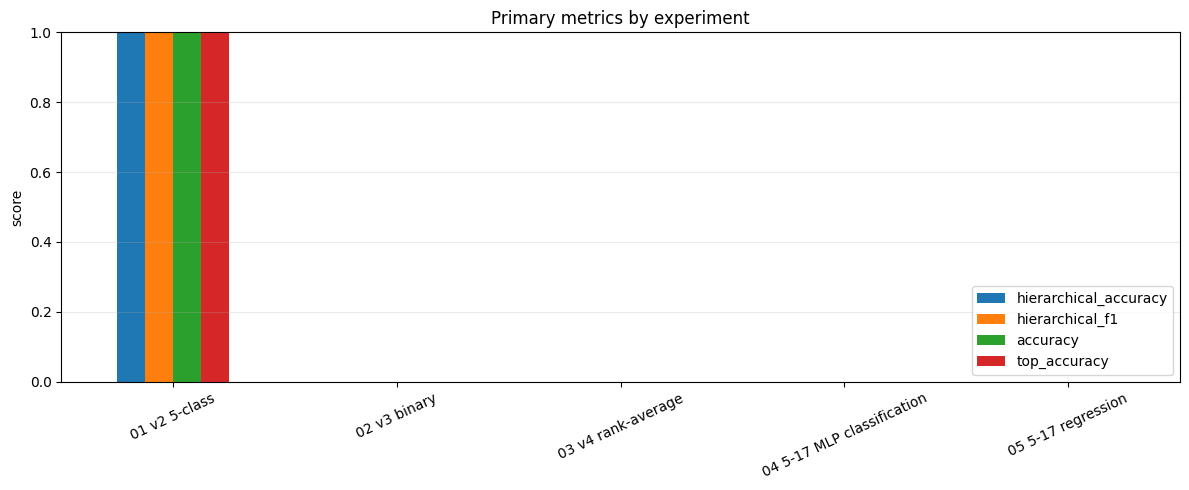

Saved: `C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\all_experiment_comparison\primary_metrics_comparison.png`

In [5]:
plot_metrics = [metric for metric in PRIMARY_METRICS if metric in comparison_df.columns and comparison_df[metric].notna().any()]

if plot_metrics:
    plot_df = comparison_df.set_index("name")[plot_metrics]
    ax = plot_df.plot(kind="bar", figsize=(12, 5), rot=25)
    ax.set_title("Primary metrics by experiment")
    ax.set_xlabel("")
    ax.set_ylabel("score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="lower right")
    plt.tight_layout()

    plot_path = COMPARISON_OUT / "primary_metrics_comparison.png"
    plt.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.show()
    display(Markdown(f"Saved: `{plot_path}`"))
else:
    display(Markdown("No primary metric columns were found in the loaded CSV files."))


## Best experiment by metric

In [6]:
best_rows = []

for metric in METRICS:
    if metric not in comparison_df.columns or comparison_df[metric].dropna().empty:
        continue
    idx = comparison_df[metric].astype(float).idxmax()
    best_rows.append({
        "metric": metric,
        "best_experiment": comparison_df.loc[idx, "name"],
        "score": comparison_df.loc[idx, metric],
        "dataset_count": comparison_df.loc[idx, "dataset_count"],
        "csv_file": comparison_df.loc[idx, "csv_file"],
    })

best_df = pd.DataFrame(best_rows)
best_csv = COMPARISON_OUT / "best_experiment_by_metric.csv"
best_df.to_csv(best_csv, index=False, encoding="utf-8-sig")

display(best_df)
display(Markdown(f"Saved: `{best_csv}`"))


,metric,best_experiment,score,dataset_count,csv_file
0,accuracy,01 v2 5-class,34.625912,15,summary_results.csv
1,hierarchical_accuracy,01 v2 5-class,41.937782,15,summary_results.csv
2,hierarchical_f1,01 v2 5-class,53.476493,15,summary_results.csv
3,hierarchical_precision,01 v2 5-class,45.976742,15,summary_results.csv
4,hierarchical_recall,01 v2 5-class,68.525189,15,summary_results.csv
5,macro_accuracy,01 v2 5-class,29.728765,15,summary_results.csv
6,macro_top_accuracy,01 v2 5-class,54.146799,15,summary_results.csv
7,top_accuracy,01 v2 5-class,60.127737,15,summary_results.csv


Saved: `C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\all_experiment_comparison\best_experiment_by_metric.csv`